In [44]:
# Cell 1: Imports and Environment Setup
import os
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 导入本地模块
from data.dataset import DeepCSDataset
from models.predictor import GraphPredictor
from models.solver import StressMajorizationSolver
from utils import load_config

# 设置绘图风格
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print("[INFO] Environment Ready.")

[INFO] Environment Ready.


In [45]:
# Cell 2: Load Config and Best Model
CONFIG_PATH = 'configs/default.yaml' # 注意确认文件夹名是 config 还是 configs
cfg = load_config(CONFIG_PATH)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Using Device: {device}")

# 1. 初始化模型架构 (V2.0)
model = GraphPredictor(
    in_channels=cfg['model']['in_channels'],
    hidden_channels=cfg['model']['hidden_channels'],
    heads=cfg['model']['heads'],
    dropout=0.0
).to(device)

# 2. 初始化求解器
solver = StressMajorizationSolver(
    iterations=100,
    epsilon=float(cfg['solver']['epsilon'])
).to(device)

# 3. 加载权重 (加入 weights_only=True 消除警告)
best_model_path = os.path.join(cfg['log']['save_dir'], cfg['log']['exp_name'], 'best_model.pth')
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

print(f"[INFO] Successfully loaded best model from: {best_model_path}")

[INFO] Using Device: cuda
[INFO] Successfully loaded best model from: checkpoints/exp_rome_3.3_baseline_stress_local_beta_norm/best_model.pth


In [47]:
# Cell 3: Multi-Target Distance Matrix Computation
import torch
import numpy as np
import networkx as nx
from torch_geometric.utils import to_dense_batch, to_dense_adj
from models.layers import DifferentiableAPSP

# 1. 辅助函数：带索引保护的传统 Floyd 算法
def get_floyd_matrix_aligned(beta_tensor, edge_index, num_nodes):
    """
    使用 NetworkX 计算 Floyd-Warshall，通过 nodelist 强制输出矩阵与 Tensor 索引对齐。
    """
    G = nx.Graph()
    # 必须显式添加所有节点，确保节点顺序固定为 0, 1, ..., N-1
    G.add_nodes_from(range(num_nodes))
    
    b_np = beta_tensor.squeeze(0).cpu().numpy()
    ei_np = edge_index.cpu().numpy()
    
    # 添加带权边
    for i in range(ei_np.shape[1]):
        u, v = ei_np[0, i], ei_np[1, i]
        G.add_edge(u, v, weight=b_np[u, v])
    
    # 【核心修复】指定 nodelist=range(num_nodes)，防止 NetworkX 内部随机排列索引
    d_np = nx.floyd_warshall_numpy(G, nodelist=range(num_nodes))
    
    return torch.from_numpy(d_np).unsqueeze(0).float().to(device)

# 2. 准备测试数据 (确保 dataset 已在 Cell 1/2 加载)
# 如果你想测试不同的图，可以修改 idx
idx = 1140 
data = dataset[idx].to(device)
N = data.num_nodes
print(f"[INFO] Processing Graph {idx} with {N} nodes.")

# 3. 准备模型预测与邻接掩码
# 3. 准备模型预测与邻接掩码
with torch.no_grad():
    # 提取特征
    h_sparse = model(data.x, data.edge_index)
    dummy_batch = torch.zeros(N, dtype=torch.long, device=device)
    h_dense, _ = to_dense_batch(h_sparse, dummy_batch, max_num_nodes=N)
    
    # 预测原始 Beta
    mask_node = torch.ones((1, N), device=device).bool()
    beta_raw = model.predict_beta(h_dense, mask_node) # [1, N, N]
    
    # --- [核心修复：局部 1-Hop 归一化] ---
    # A. 获取拓扑掩码并排除自环
    adj_mask = to_dense_adj(data.edge_index, max_num_nodes=N).bool().to(device)
    eye = torch.eye(N, device=device).bool().unsqueeze(0)
    valid_edge_mask = adj_mask & (~eye) # 仅保留真实的、非自环的物理边
    edge_mask_float = valid_edge_mask.float()
    
    # B. 仅计算这 64 条真实边的局部均值
    beta_1hop_sum = (beta_raw * edge_mask_float).sum(dim=(1, 2), keepdim=True)
    edge_count = edge_mask_float.sum(dim=(1, 2), keepdim=True).clamp(min=1.0)
    beta_1hop_mean = beta_1hop_sum / edge_count
    
    # C. 归一化：确保诊断时的 Mean Value 必须是 1.0
    beta_model = (beta_raw / (beta_1hop_mean + 1e-8)).clamp(min=0.1, max=5.0)
    
    # 为了兼容你后面的诊断代码，定义 beta_norm
    beta_norm = beta_model 
    
    # 生成全 1 对比组
    beta_ones = torch.ones_like(beta_model)

# 4. 实例化可微层 (建议推理时温度 T=0.1 以获得更接近真实距离的输出)
apsp_layer = DifferentiableAPSP(temperature=0.1).to(device)

print("[INFO] Computing 4 Target Distance Matrices...")

# --- [A 组：模型预测逻辑验证] ---
# Target 1: 模型预测的 Beta + 可微 APSP 层 (GPU)
d_target1 = apsp_layer(beta_model * adj_mask.float(), adj_mask)

# Target 2: 模型预测的 Beta + 传统 Floyd 算法 (CPU-Aligned)
d_target2 = get_floyd_matrix_aligned(beta_model, data.edge_index, N)

# --- [B 组：算子功能还原验证 (消融实验)] ---
# Target 3: 全 1 的 Beta + 可微 APSP 层 (GPU)
d_target3 = apsp_layer(beta_ones * adj_mask.float(), adj_mask)

# Target 4: 全 1 的 Beta + 传统 Floyd 算法 (CPU-Aligned)
d_target4 = get_floyd_matrix_aligned(beta_ones, data.edge_index, N)

# 5. 准备评估基准 (原始图论最短路径 & 权重)
d_sp_gt = data.d_sp.unsqueeze(0).to(device)
weights = data.weights.unsqueeze(0).to(device)

# --- 在 Cell 3 末尾添加以下逻辑 ---

# 1. 提取 1-hop 边的索引 (u, v)
u_idx, v_idx = data.edge_index[0], data.edge_index[1]

# 2. 从预测的全局矩阵中提取对应的 beta 值
# beta_norm 形状是 [1, N, N]
beta_1hop_vals = beta_norm[0, u_idx, v_idx]

# 3. 打印 1-hop 数据的健康诊断
print("\n" + "="*30)
print("1-HOP BETA DIAGNOSTICS")
print("-" * 30)

print(f"Edge Count: {len(beta_1hop_vals)}")
print(f"Mean Value: {beta_1hop_vals.mean().item():.4f} (Ideal: 1.0)")
print(f"Std Dev:    {beta_1hop_vals.std().item():.4f}")
print(f"Min / Max:  {beta_1hop_vals.min().item():.4f} / {beta_1hop_vals.max().item():.4f}")
print("="*30)
print(f"[INFO] Setup Complete. Ready for Cell 4 visualization.")

[INFO] Processing Graph 1140 with 27 nodes.
[INFO] Computing 4 Target Distance Matrices...

1-HOP BETA DIAGNOSTICS
------------------------------
Edge Count: 64
Mean Value: 1.0000 (Ideal: 1.0)
Std Dev:    0.0166
Min / Max:  0.9609 / 1.0322
[INFO] Setup Complete. Ready for Cell 4 visualization.


[INFO] Initializing Graph Structure...
[INFO] Solving all 5 layouts...


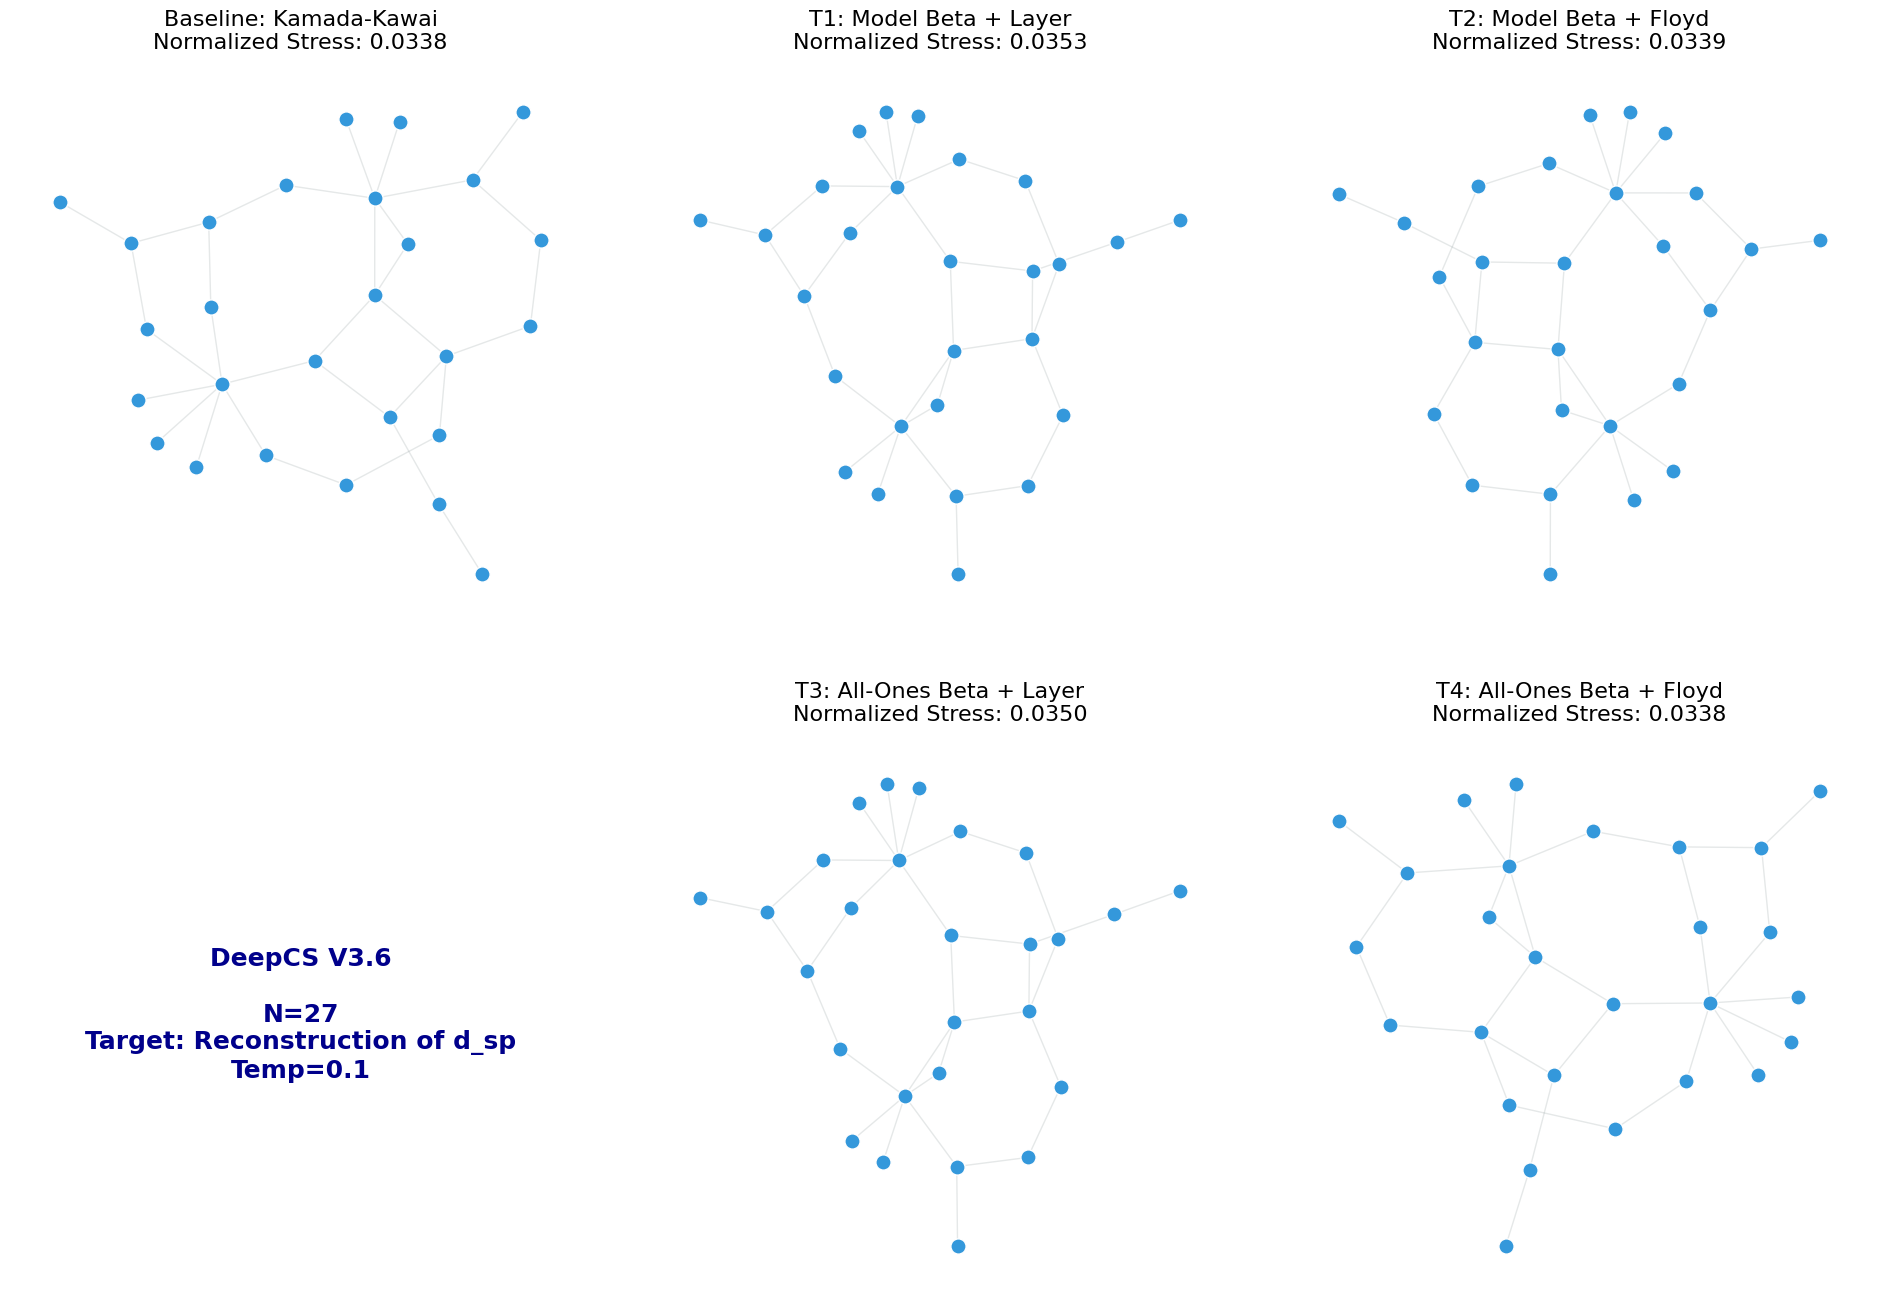

In [48]:
# Cell 4: 5-Layout Visualization & Stress Analysis (Final Robust Version)
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def solve_and_evaluate(target_d, weights_d, gt_d_sp):
    """
    求解坐标并计算基于最优缩放因子 s 的 Normalized Stress。
    Args:
        target_d: 模型预测或算法计算的理想距离矩阵 [1, N, N]
        weights_d: 求解权重 [1, N, N]
        gt_d_sp: 原始图论最短路径 (监督真值) [1, N, N]
    """
    N_local = target_d.shape[1]
    init_pos = torch.randn(1, N_local, 2, device=device)
    
    # 1. 运行 Solver 获取原始坐标
    pos = solver(init_pos, weights_d, target_d, mask)
    pos_np = pos.squeeze(0).cpu().numpy()
    
    # 2. 尺度对齐计算 (Optimal Scaling)
    d_sp_np = gt_d_sp.squeeze(0).cpu().numpy()
    w_np = weights_d.squeeze(0).cpu().numpy()
    
    # 计算当前布局的物理欧氏距离
    diff = pos_np[:, np.newaxis, :] - pos_np[np.newaxis, :, :]
    dist_curr = np.linalg.norm(diff, axis=-1)
    
    # 排除对角线
    m = ~np.eye(N_local, dtype=bool)
    
    # 最优缩放因子 s = sum(w * d_gt * dist_curr) / sum(w * dist_curr^2)
    s = np.sum(w_np[m] * d_sp_np[m] * dist_curr[m]) / (np.sum(w_np[m] * dist_curr[m]**2) + 1e-12)
    
    # 3. 计算 Normalized Stress (对标原始图论结构)
    # Stress = sum( w * (s*dist_curr - d_gt)^2 ) / sum( w * d_gt^2 )
    stress_val = np.sum(w_np[m] * (s * dist_curr[m] - d_sp_np[m])**2)
    normalization = np.sum(w_np[m] * d_sp_np[m]**2) + 1e-12
    
    return pos_np, stress_val / normalization

# --- 1. 准备基础图结构 (修正 NetworkX 转换逻辑) ---
print("[INFO] Initializing Graph Structure...")
G_vis = nx.Graph()
G_vis.add_nodes_from(range(N))
# 显式添加边表
edges_np = data.edge_index.cpu().numpy().T
G_vis.add_edges_from(edges_np)

# --- 2. 计算所有 5 种布局 ---
print("[INFO] Solving all 5 layouts...")

# (0) Baseline: Kamada-Kawai
pos_kk_dict = nx.kamada_kawai_layout(G_vis, weight=None)
pos_kk = np.array([pos_kk_dict[i] for i in range(N)])
# 计算 KK 的 Stress (同样使用 s 因子对齐)
dist_kk = np.linalg.norm(pos_kk[:, None, :] - pos_kk[None, :, :], axis=-1)
m_diag = ~np.eye(N, dtype=bool)
d_sp_np = d_sp_gt.squeeze(0).cpu().numpy()
w_np = weights.squeeze(0).cpu().numpy()
s_kk = np.sum(w_np[m_diag] * d_sp_np[m_diag] * dist_kk[m_diag]) / (np.sum(w_np[m_diag] * dist_kk[m_diag]**2) + 1e-12)
stress_kk = np.sum(w_np[m_diag] * (s_kk * dist_kk[m_diag] - d_sp_np[m_diag])**2) / (np.sum(w_np[m_diag] * d_sp_np[m_diag]**2) + 1e-12)

# (1) Target 1: 模型 Beta + Differentiable Layer
pos1, s1 = solve_and_evaluate(d_target1, weights, d_sp_gt)

# (2) Target 2: 模型 Beta + Traditional Floyd
pos2, s2 = solve_and_evaluate(d_target2, weights, d_sp_gt)

# (3) Target 3: 全 1 Beta + Differentiable Layer
pos3, s3 = solve_and_evaluate(d_target3, weights, d_sp_gt)

# (4) Target 4: 全 1 Beta + Traditional Floyd
pos4, s4 = solve_and_evaluate(d_target4, weights, d_sp_gt)

# --- 3. 2x3 矩阵可视化 ---
fig, axes = plt.subplots(2, 3, figsize=(24, 16), dpi=100)
plt.subplots_adjust(hspace=0.2, wspace=0.1)

plot_configs = [
    (pos_kk, f"Baseline: Kamada-Kawai\nNormalized Stress: {stress_kk:.4f}", axes[0, 0]),
    (pos1, f"T1: Model Beta + Layer\nNormalized Stress: {s1:.4f}", axes[0, 1]),
    (pos2, f"T2: Model Beta + Floyd\nNormalized Stress: {s2:.4f}", axes[0, 2]),
    (None, "Experiment: Reconstruction Analysis", axes[1, 0]),
    (pos3, f"T3: All-Ones Beta + Layer\nNormalized Stress: {s3:.4f}", axes[1, 1]),
    (pos4, f"T4: All-Ones Beta + Floyd\nNormalized Stress: {s4:.4f}", axes[1, 2])
]

for pos_np, title, ax in plot_configs:
    if pos_np is None:
        ax.text(0.5, 0.5, f"DeepCS V3.6\n\nN={N}\nTarget: Reconstruction of d_sp\nTemp={apsp_layer.temperature}", 
                ha='center', va='center', fontsize=18, fontweight='bold', color='darkblue')
        ax.axis('off')
        continue
    
    # 绘制节点与边
    nx.draw_networkx_nodes(G_vis, pos_np, ax=ax, node_size=120, 
                           node_color='#3498db', edgecolors='white', linewidths=1)
    nx.draw_networkx_edges(G_vis, pos_np, ax=ax, alpha=0.2, edge_color='#7f8c8d', width=1)
    
    ax.set_title(title, fontsize=16, pad=10)
    ax.axis('off')

plt.show()

In [38]:
# Cell 5: 使用完全一致的 Normalized Stress 逻辑进行校验
def check_actual_model_loss(pos_np, d_gt_tensor):
    """
    完全复现 PureStressLoss 的 forward 逻辑
    pos_np: 布局坐标 [N, 2]
    d_gt_tensor: 监督目标 [1, N, N]
    """
    with torch.no_grad():
        final_pos = torch.from_numpy(pos_np).unsqueeze(0).float().to(device)
        mask_mat = mask.float().unsqueeze(2) * mask.float().unsqueeze(1)
        
        # 1. 计算欧氏距离
        dist_curr = torch.cdist(final_pos, final_pos, p=2).clamp(min=1e-8)
        
        # 2. 计算最优缩放因子 s (严格复现模型代码)
        num = (weights * d_gt_tensor * dist_curr * mask_mat).sum(dim=(1, 2), keepdim=True)
        den = (weights * (dist_curr**2) * mask_mat).sum(dim=(1, 2), keepdim=True)
        s = num / (den + 1e-12)
        
        # 3. 计算 Normalized Stress
        num_stress = (weights * (s * dist_curr - d_gt_tensor)**2 * mask_mat).sum()
        den_stress = (weights * d_gt_tensor**2 * mask_mat).sum() + 1e-12
        
        loss_normalized = num_stress / den_stress
        return loss_normalized.item()

print("[INFO] Final Validation (Using exact PureStressLoss logic):")
print(f"-> KK Baseline:    {check_actual_model_loss(pos_kk, d_sp_gt):.6f}")
print(f"-> T1 (Model+Layer): {check_actual_model_loss(pos1, d_sp_gt):.6f}")
print(f"-> T3 (Ones+Layer):  {check_actual_model_loss(pos3, d_sp_gt):.6f}")
print(f"-> T4 (Ones+Floyd):  {check_actual_model_loss(pos4, d_sp_gt):.6f}")

[INFO] Final Validation (Using exact PureStressLoss logic):
-> KK Baseline:    0.033842
-> T1 (Model+Layer): 0.035550
-> T3 (Ones+Layer):  0.035050
-> T4 (Ones+Floyd):  0.058387
